<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2026/blob/main/DISE%C3%91O2026PARTE6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos**

<a name="inicio6"></a>

# **6. Diseños Factoriales - P6**

## **https://rpubs.com/jseferino/DOEP6**


## **41.** [EJEMPLO: DISEÑO FACTORIAL 2^2](#T41)

## **42.** [EJEMPLO: DISEÑO FACTORIAL 4x3](#T42)

## **43.** [EJEMPLO: DISEÑO FACTORIAL 3x2x2 -  VOLUMEN DE SEDIMENTACIÓN](#T43)

## **44.** [D](#T44)

## **45.** [E](#T45)

## **46.** [A](#T46)

## **47.** [B](#T47)

## **48.** [C](#T48)

## **49.** [D](#T49)

## **50.** [E](#T50)

[⬆️ Volver al inicio](#inicio6)

<a name="T41"></a>
## **41. EJEMPLO: DISEÑO FACTORIAL 2^2**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Efecto de A (tiempo): -0.72 
Efecto de B (velocidad): 1.78 
Efecto de interacción AB: 0.12 


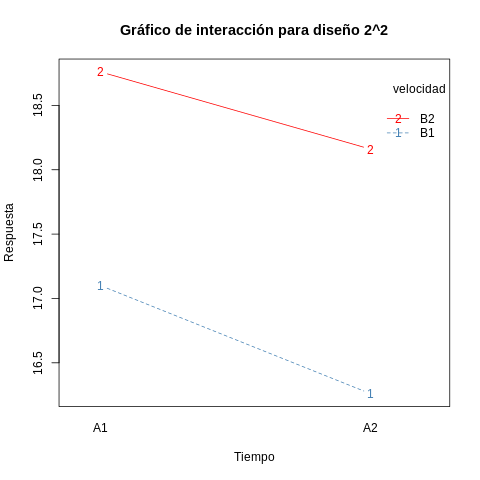

In [ ]:


# ============================================
# @title **B. EJEMPLO: DISEÑO FACTORIAL 2^2**
# ============================================
%%R
# Datos
tiempo <- factor(c("A1", "A2", "A1", "A2"))
velocidad <- factor(c("B1", "B1", "B2", "B2"))
respuesta <- c(17.10, 16.26, 18.76, 18.16)

datos <- data.frame(tiempo, velocidad, respuesta)

# Modelo ANOVA
modelo <- aov(respuesta ~ tiempo * velocidad, data = datos)
summary(modelo)

# Cálculo manual de efectos
Y_A1_B1 <- 17.10
Y_A2_B1 <- 16.26
Y_A1_B2 <- 18.76
Y_A2_B2 <- 18.16

efecto_A <- (Y_A2_B1 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A1_B2)/2
efecto_B <- (Y_A1_B2 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A2_B1)/2
efecto_AB <- (Y_A1_B1 + Y_A2_B2)/2 - (Y_A1_B2 + Y_A2_B1)/2

cat("Efecto de A (tiempo):", round(efecto_A, 2), "\n")
cat("Efecto de B (velocidad):", round(efecto_B, 2), "\n")
cat("Efecto de interacción AB:", round(efecto_AB, 2), "\n")

# Gráfico de interacción
interaction.plot(tiempo, velocidad, respuesta,
                 type = "b", col = c("steelblue", "red"),
                 xlab = "Tiempo", ylab = "Respuesta",
                 main = "Gráfico de interacción para diseño 2^2")



=== DISEÑO FACTORIAL 2^2 (UNA RÉPLICA) ===

⚠️ NOTA: Con una sola réplica no es posible estimar el error experimental.
No se pueden calcular valores F ni valores-p en el ANOVA.

=== CÁLCULO DE EFECTOS ===
Efecto de A (tiempo): -0.72
Efecto de B (velocidad): 1.78
Efecto de interacción AB: 0.12


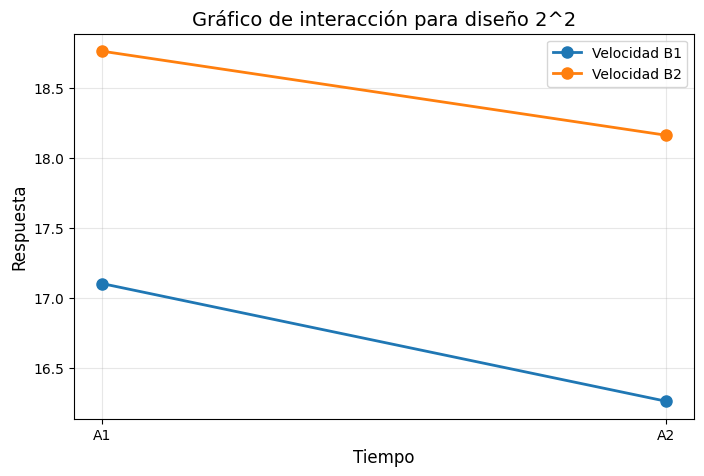


ANÁLISIS CON 2 RÉPLICAS (PARA DEMOSTRACIÓN)

=== ANOVA DISEÑO FACTORIAL 2^2 (CON 2 RÉPLICAS) ===
                          sum_sq   df            F        PR(>F)
C(tiempo)               0.973012  1.0  1066.315068  5.244086e-06
C(velocidad)            6.498013  1.0  7121.109589  1.182087e-07
C(tiempo):C(velocidad)  0.019012  1.0    20.835616  1.030281e-02
Residual                0.003650  4.0          NaN           NaN


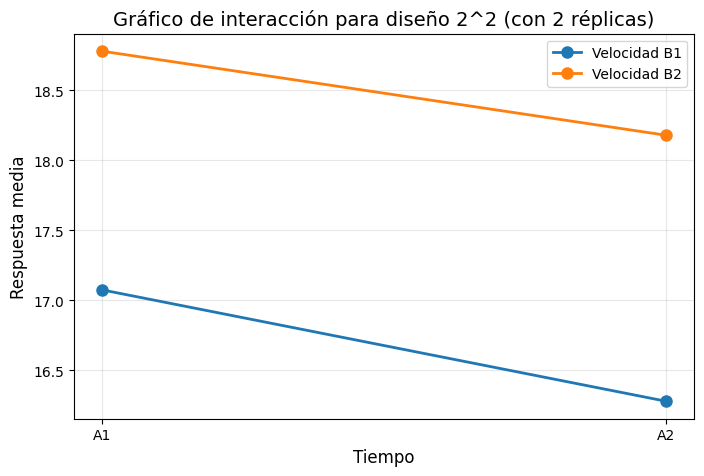

In [ ]:
# ============================================
# @title **C. EJEMPLO: DISEÑO FACTORIAL 2^2**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ============================================
# PARTE 1: DATOS CON UNA SOLA RÉPLICA
# ============================================

# Datos (una sola réplica)
datos = pd.DataFrame({
    'tiempo': ['A1', 'A2', 'A1', 'A2'],
    'velocidad': ['B1', 'B1', 'B2', 'B2'],
    'respuesta': [17.10, 16.26, 18.76, 18.16]
})

print("=== DISEÑO FACTORIAL 2^2 (UNA RÉPLICA) ===\n")
print("⚠️ NOTA: Con una sola réplica no es posible estimar el error experimental.")
print("No se pueden calcular valores F ni valores-p en el ANOVA.\n")

# ============================================
# CÁLCULO MANUAL DE EFECTOS
# ============================================

Y_A1_B1, Y_A2_B1, Y_A1_B2, Y_A2_B2 = 17.10, 16.26, 18.76, 18.16

# Efecto principal de A (tiempo)
efecto_A = (Y_A2_B1 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A1_B2)/2

# Efecto principal de B (velocidad)
efecto_B = (Y_A1_B2 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A2_B1)/2

# Efecto de interacción AB
efecto_AB = (Y_A1_B1 + Y_A2_B2)/2 - (Y_A1_B2 + Y_A2_B1)/2

print("=== CÁLCULO DE EFECTOS ===")
print(f"Efecto de A (tiempo): {efecto_A:.2f}")
print(f"Efecto de B (velocidad): {efecto_B:.2f}")
print(f"Efecto de interacción AB: {efecto_AB:.2f}")

# ============================================
# GRÁFICO DE INTERACCIÓN
# ============================================

plt.figure(figsize=(8, 5))

# Obtener valores únicos de velocidad
velocidades = datos['velocidad'].unique()

for vel in velocidades:
    # Filtrar datos para cada nivel de velocidad
    subdatos = datos[datos['velocidad'] == vel]
    # Ordenar por tiempo para una línea continua
    subdatos = subdatos.sort_values('tiempo')
    plt.plot(subdatos['tiempo'], subdatos['respuesta'],
             'o-', label=f'Velocidad {vel}', markersize=8, linewidth=2)

plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Respuesta', fontsize=12)
plt.title('Gráfico de interacción para diseño 2^2', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# PARTE 2: DATOS CON 2 RÉPLICAS (PARA DEMOSTRACIÓN)
# ============================================

print("\n" + "="*60)
print("ANÁLISIS CON 2 RÉPLICAS (PARA DEMOSTRACIÓN)")
print("="*60)

# Datos con 2 réplicas
datos_2replicas = pd.DataFrame({
    'tiempo': ['A1', 'A1', 'A2', 'A2', 'A1', 'A1', 'A2', 'A2'],
    'velocidad': ['B1', 'B1', 'B1', 'B1', 'B2', 'B2', 'B2', 'B2'],
    'respuesta': [17.10, 17.05, 16.26, 16.30, 18.76, 18.80, 18.16, 18.20]
})

# Modelo ANOVA con réplicas
modelo_rep = ols('respuesta ~ C(tiempo) * C(velocidad)', data=datos_2replicas).fit()
anova_table = sm.stats.anova_lm(modelo_rep, typ=2)

print("\n=== ANOVA DISEÑO FACTORIAL 2^2 (CON 2 RÉPLICAS) ===")
print(anova_table)

# ============================================
# GRÁFICO DE INTERACCIÓN CON 2 RÉPLICAS
# ============================================

plt.figure(figsize=(8, 5))

# Calcular medias por combinación
medias = datos_2replicas.groupby(['tiempo', 'velocidad'])['respuesta'].mean().reset_index()

for vel in medias['velocidad'].unique():
    subdatos = medias[medias['velocidad'] == vel]
    subdatos = subdatos.sort_values('tiempo')
    plt.plot(subdatos['tiempo'], subdatos['respuesta'],
             'o-', label=f'Velocidad {vel}', markersize=8, linewidth=2)

plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Respuesta media', fontsize=12)
plt.title('Gráfico de interacción para diseño 2^2 (con 2 réplicas)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[⬆️ Volver al inicio](#inicio6)

<a name="T42"></a>
## **42. EJEMPLO: DISEÑO FACTORIAL 4x3**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== MEDIAS POR PROFUNDIDAD ===
# A tibble: 4 × 2
  profundidad media
  <fct>       <dbl>
1 0.15         84.8
2 0.18         89.8
3 0.21         97.9
4 0.24        105. 

=== MEDIAS POR VELOCIDAD ===
# A tibble: 3 × 2
  velocidad media
  <fct>     <dbl>
1 0.2        81.6
2 0.25       97.6
3 0.3       104. 

=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===
SCA = 2125.11 
SCB = 3160.5 
SCAB = 557.06 
SCE = 689.33 
SCT = 6532 

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 28.72 
t crítico = 2.0639 
LSD para comparar profundidades en velocidad 0.25 = 9.03 
Medias en velocidad 0.25:
  Profundidad 0.15: 88.67
  Profundidad 0.18: 96.67
  Profundidad 0.21: 100.67
  Profundidad 0.24: 104.33


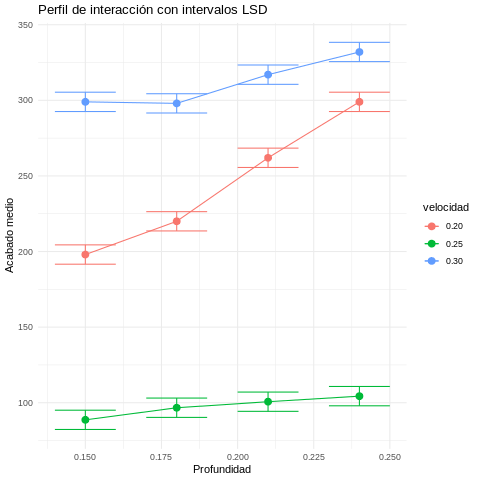

In [ ]:


# ============================================
# @title **B. EJEMPLO: DISEÑO FACTORIAL 4x3**
# ============================================
%%R
# Crear datos
profundidad <- rep(c(0.15, 0.18, 0.21, 0.24), each = 9)
velocidad <- rep(rep(c(0.20, 0.25, 0.30), each = 3), times = 4)
acabado <- c(74, 64, 60, 92, 86, 88, 99, 98, 102,      # A=0.15
             79, 68, 73, 98, 104, 88, 104, 99, 95,     # A=0.18
             82, 88, 92, 99, 108, 95, 108, 110, 99,    # A=0.21
             99, 104, 96, 104, 110, 99, 114, 111, 107) # A=0.24

datos <- data.frame(profundidad = factor(profundidad),
                    velocidad = factor(velocidad),
                    acabado)

# Estadísticos descriptivos
library(dplyr)
medias_prof <- datos %>% group_by(profundidad) %>% summarise(media = mean(acabado))
medias_vel <- datos %>% group_by(velocidad) %>% summarise(media = mean(acabado))

cat("=== MEDIAS POR PROFUNDIDAD ===\n")
print(medias_prof)

cat("\n=== MEDIAS POR VELOCIDAD ===\n")
print(medias_vel)

# ANOVA factorial
modelo <- aov(acabado ~ profundidad * velocidad, data = datos)
summary(modelo)

# Gráfico de interacción
interaction.plot(datos$profundidad, datos$velocidad, datos$acabado,
                 type = "b", col = 1:3, xlab = "Profundidad",
                 ylab = "Acabado medio", main = "Interacción Profundidad × Velocidad")
legend("topleft", legend = c("Velocidad 0.20", "Velocidad 0.25", "Velocidad 0.30"),
       col = 1:3, lty = 1, bty = "n")

# Cálculo manual de sumas de cuadrados
a <- 4; b <- 3; n <- 3
N <- a * b * n
Y_total <- 3396
correccion <- Y_total^2 / N

# Suma total de cuadrados
SCT <- sum(acabado^2) - correccion

# Suma de cuadrados de A (profundidad)
Y_A <- tapply(acabado, profundidad, sum)
SCA <- sum(Y_A^2) / (b * n) - correccion

# Suma de cuadrados de B (velocidad)
Y_B <- tapply(acabado, velocidad, sum)
SCB <- sum(Y_B^2) / (a * n) - correccion

# Suma de cuadrados de la interacción AB
Y_AB <- tapply(acabado, list(profundidad, velocidad), sum)
SCAB <- sum(Y_AB^2) / n - correccion - SCA - SCB

# Suma de cuadrados del error
SCE <- SCT - SCA - SCB - SCAB

cat("\n=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===\n")
cat("SCA =", round(SCA, 2), "\n")
cat("SCB =", round(SCB, 2), "\n")
cat("SCAB =", round(SCAB, 2), "\n")
cat("SCE =", round(SCE, 2), "\n")
cat("SCT =", round(SCT, 2), "\n")

# Comparaciones múltiples (LSD) con interacción
CME <- SCE / (a * b * (n - 1))
gl_error <- a * b * (n - 1)
t_crit <- qt(0.975, gl_error)

# LSD para comparar niveles de A dentro de un nivel específico de B
# Por ejemplo, para velocidad = 0.25 (B2)
Y_AB_B2 <- Y_AB[, 2]  # Velocidad 0.25 (segunda columna)
medias_B2 <- Y_AB_B2 / n
LSD_B2 <- t_crit * sqrt(2 * CME / n)

cat("\n=== COMPARACIONES MÚLTIPLES (LSD) ===\n")
cat("CME =", round(CME, 2), "\n")
cat("t crítico =", round(t_crit, 4), "\n")
cat("LSD para comparar profundidades en velocidad 0.25 =", round(LSD_B2, 2), "\n")
cat("Medias en velocidad 0.25:\n")
for(i in 1:4) {
  cat(sprintf("  Profundidad %.2f: %.2f\n", as.numeric(levels(datos$profundidad)[i]), medias_B2[i]))
}

# Gráfico con intervalos LSD
library(ggplot2)
medias_AB <- data.frame(
  profundidad = rep(as.numeric(levels(datos$profundidad)), 3),
  velocidad = rep(c("0.20", "0.25", "0.30"), each = 4),
  media = c(rowMeans(matrix(Y_AB[,1], nrow=4)), medias_B2, rowMeans(matrix(Y_AB[,3], nrow=4))),
  error = rep(sqrt(CME / n) * t_crit, 3)
)

ggplot(medias_AB, aes(x = profundidad, y = media, color = velocidad)) +
  geom_point(size = 3) +
  geom_line() +
  geom_errorbar(aes(ymin = media - error, ymax = media + error), width = 0.02) +
  labs(title = "Perfil de interacción con intervalos LSD",
       x = "Profundidad", y = "Acabado medio") +
  theme_minimal()




=== MEDIAS POR PROFUNDIDAD ===
profundidad
0.15     84.777778
0.18     89.777778
0.21     97.888889
0.24    104.888889
Name: acabado, dtype: float64

=== MEDIAS POR VELOCIDAD ===
velocidad
0.20     81.583333
0.25     97.583333
0.30    103.833333
Name: acabado, dtype: float64

=== ANOVA FACTORIAL 4x3 ===
                                  sum_sq    df          F        PR(>F)
C(profundidad)               2125.111111   3.0  24.662798  1.652000e-07
C(velocidad)                 3160.500000   2.0  55.018375  1.086046e-09
C(profundidad):C(velocidad)   557.055556   6.0   3.232431  1.797302e-02
Residual                      689.333333  24.0        NaN           NaN

=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===
SCA = 2125.11
SCB = 3160.50
SCAB = 557.06
SCE = 689.33
SCT = 6532.00

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 28.72
t crítico = 2.0639
LSD para comparar profundidades en velocidad 0.25 = 9.03
Medias en velocidad 0.25:
  Profundidad 0.15: 88.67
  Profundidad 0.18: 96.67
  Profundidad 0

/tmp/ipykernel_37615/3154935570.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('profundidad')['acabado'].mean())
/tmp/ipykernel_37615/3154935570.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('velocidad')['acabado'].mean())
/tmp/ipykernel_37615/3154935570.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Y_A = datos.groupby('profundidad')['acabado'].sum().values
/tmp

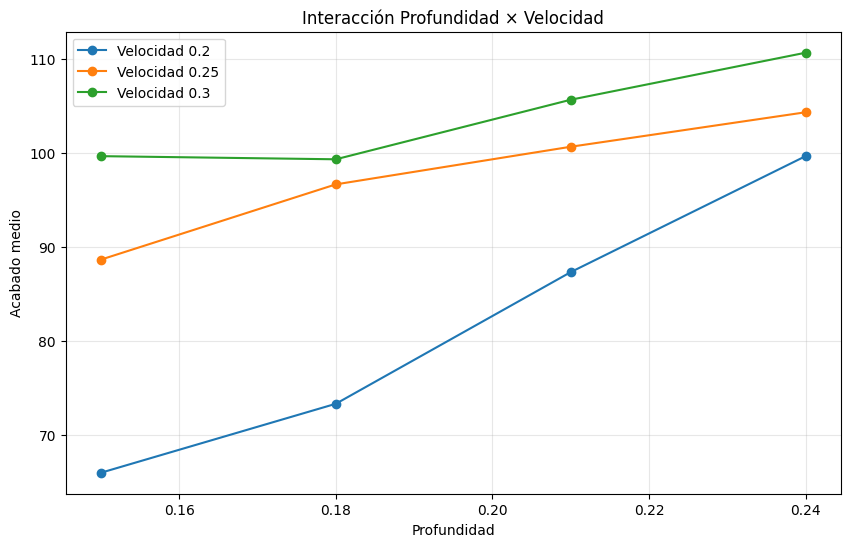

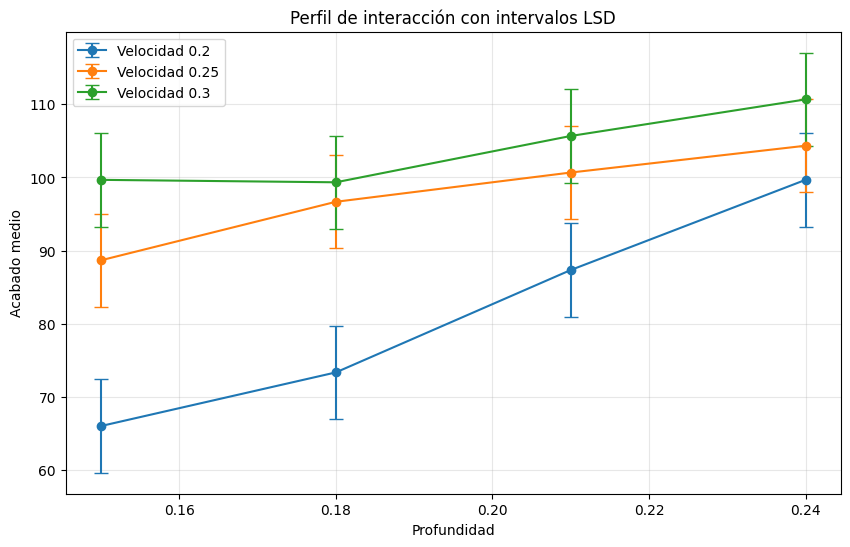

In [ ]:
# ============================================
# @title **C. EJEMPLO: DISEÑO FACTORIAL 4x3**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import f, t

# Crear datos
profundidad = [0.15]*9 + [0.18]*9 + [0.21]*9 + [0.24]*9
velocidad = [0.20]*3 + [0.25]*3 + [0.30]*3
velocidad = velocidad * 4
acabado = [74, 64, 60, 92, 86, 88, 99, 98, 102,      # A=0.15
           79, 68, 73, 98, 104, 88, 104, 99, 95,     # A=0.18
           82, 88, 92, 99, 108, 95, 108, 110, 99,    # A=0.21
           99, 104, 96, 104, 110, 99, 114, 111, 107] # A=0.24

datos = pd.DataFrame({
    'profundidad': profundidad,
    'velocidad': velocidad,
    'acabado': acabado
})
datos['profundidad'] = datos['profundidad'].astype('category')
datos['velocidad'] = datos['velocidad'].astype('category')

# Estadísticos descriptivos
print("=== MEDIAS POR PROFUNDIDAD ===")
print(datos.groupby('profundidad')['acabado'].mean())

print("\n=== MEDIAS POR VELOCIDAD ===")
print(datos.groupby('velocidad')['acabado'].mean())

# ANOVA factorial
modelo = ols('acabado ~ C(profundidad) * C(velocidad)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("\n=== ANOVA FACTORIAL 4x3 ===")
print(anova_table)

# Cálculo manual de sumas de cuadrados
a, b, n = 4, 3, 3
N = a * b * n
Y_total = 3396
correccion = Y_total**2 / N

# Suma total de cuadrados
SCT = np.sum(np.array(acabado)**2) - correccion

# Suma de cuadrados de A (profundidad)
Y_A = datos.groupby('profundidad')['acabado'].sum().values
SCA = np.sum(Y_A**2) / (b * n) - correccion

# Suma de cuadrados de B (velocidad)
Y_B = datos.groupby('velocidad')['acabado'].sum().values
SCB = np.sum(Y_B**2) / (a * n) - correccion

# Suma de cuadrados de interacción AB
Y_AB = datos.groupby(['profundidad', 'velocidad'])['acabado'].sum().values
SCAB = np.sum(Y_AB**2) / n - correccion - SCA - SCB

# Suma de cuadrados del error
SCE = SCT - SCA - SCB - SCAB

print("\n=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===")
print(f"SCA = {SCA:.2f}")
print(f"SCB = {SCB:.2f}")
print(f"SCAB = {SCAB:.2f}")
print(f"SCE = {SCE:.2f}")
print(f"SCT = {SCT:.2f}")

# Comparaciones múltiples (LSD) con interacción
gl_error = a * b * (n - 1)
CME = SCE / gl_error
t_crit = t.ppf(0.975, gl_error)

# LSD para comparar niveles de A dentro de velocidad 0.25
Y_AB_matrix = np.array(Y_AB).reshape(a, b)
medias_B2 = Y_AB_matrix[:, 1] / n
LSD_B2 = t_crit * np.sqrt(2 * CME / n)

print("\n=== COMPARACIONES MÚLTIPLES (LSD) ===")
print(f"CME = {CME:.2f}")
print(f"t crítico = {t_crit:.4f}")
print(f"LSD para comparar profundidades en velocidad 0.25 = {LSD_B2:.2f}")
print("Medias en velocidad 0.25:")
for i, prof in enumerate([0.15, 0.18, 0.21, 0.24]):
    print(f"  Profundidad {prof}: {medias_B2[i]:.2f}")

# Gráfico de interacción
plt.figure(figsize=(10, 6))
for vel in sorted(datos['velocidad'].unique()):
    subdatos = datos[datos['velocidad'] == vel]
    medias = subdatos.groupby('profundidad')['acabado'].mean()
    plt.plot(medias.index, medias.values, 'o-', label=f'Velocidad {vel}')
plt.xlabel('Profundidad')
plt.ylabel('Acabado medio')
plt.title('Interacción Profundidad × Velocidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico con intervalos LSD
fig, ax = plt.subplots(figsize=(10, 6))
for i, vel in enumerate(sorted(datos['velocidad'].unique())):
    medias = Y_AB_matrix[:, i] / n
    error = np.sqrt(CME / n) * t_crit
    ax.errorbar([0.15, 0.18, 0.21, 0.24], medias, yerr=error,
                marker='o', label=f'Velocidad {vel}', capsize=5)
ax.set_xlabel('Profundidad')
ax.set_ylabel('Acabado medio')
ax.set_title('Perfil de interacción con intervalos LSD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


[⬆️ Volver al inicio](#inicio6)

<a name="T43"></a>
## **43.EJEMPLO: DISEÑO FACTORIAL 3x2x2 -  VOLUMEN DE SEDIMENTACIÓN**

In [3]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== ESTRUCTURA DEL DISEÑO ===
'data.frame':	108 obs. of  4 variables:
 $ A      : Factor w/ 3 levels "A1","A2","A3": 1 1 1 1 1 1 1 1 1 1 ...
 $ B      : Factor w/ 2 levels "B1","B2": 1 1 1 1 1 1 1 1 1 1 ...
 $ C      : Factor w/ 2 levels "C1","C2": 1 1 1 1 1 1 1 1 1 2 ...
 $ volumen: num  60 75 75 86 70 70 55 53 53 55 ...

, ,  = C1

    
     B1 B2
  A1  9  9
  A2  9  9
  A3  9  9

, ,  = C2

    
     B1 B2
  A1  9  9
  A2  9  9
  A3  9  9


=== ESTADÍSTICAS DESCRIPTIVAS ===
    A  B  C  volumen
1  A1 B1 C1 66.33333
2  A2 B1 C1 59.33333
3  A3 B1 C1 65.11111
4  A1 B2 C1 64.11111
5  A2 B2 C1 71.44444
6  A3 B2 C1 68.88889
7  A1 B1 C2 54.44444
8  A2 B1 C2 48.44444
9  A3 B1 C2 52.44444
10 A1 B2 C2 52.88889
11 A2 B2 C2 61.33333
12 A3 B2 C2 53.55556

    A  B  C volumen.n volumen.media volumen.sd
1  A1 B1 C1  9.000000     66.333333  11.661904
2  A2 B1 C1  9.000000     59.333333  11.895377
3  A3 B1 C1  9.000000     65.111111  10.867894
4  A1 B2 C1  9.000000     64.111111   8.283182
5  A2 B2 

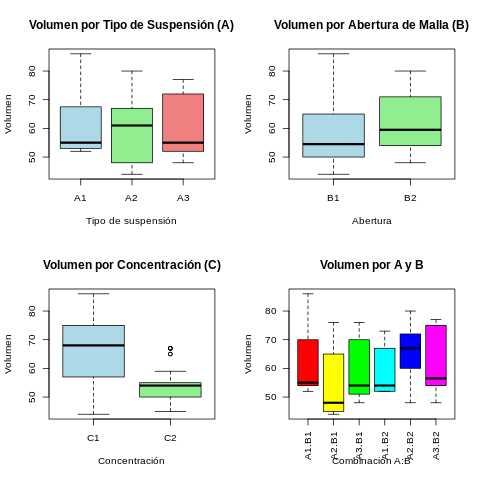

In [4]:
# ============================================
# DISEÑO FACTORIAL 3x2x2 COMPLETO
# ANÁLISIS DE VOLUMEN DE SEDIMENTACIÓN
# ============================================
%%R
# 1. PREPARACIÓN DE DATOS ============================================
# Crear estructura factorial balanceada

# Factor A: Tipo de suspensión (3 niveles)
# Factor B: Abertura de malla (2 niveles)
# Factor C: Concentración (2 niveles)

A <- factor(rep(c("A1", "A2", "A3"), each = 36))
B <- factor(rep(rep(c("B1", "B2"), each = 18), times = 3))
C <- factor(rep(rep(c("C1", "C2"), each = 9), times = 6))

# Datos de volumen de sedimentación
volumen <- c(
  # A1, B1, C1
  60, 75, 75, 86, 70, 70, 55, 53, 53,
  # A1, B1, C2
  55, 55, 55, 55, 55, 55, 52, 54, 54,
  # A1, B2, C1
  67, 73, 73, 67, 68, 68, 52, 52, 57,
  # A1, B2, C2
  52, 54, 54, 52, 54, 54, 52, 52, 52,
  # A2, B1, C1
  62, 68, 65, 76, 65, 65, 44, 44, 45,
  # A2, B1, C2
  48, 48, 45, 48, 48, 45, 52, 48, 54,
  # A2, B2, C1
  71, 80, 80, 72, 80, 80, 60, 60, 60,
  # A2, B2, C2
  67, 67, 65, 67, 67, 65, 52, 48, 54,
  # A3, B1, C1
  70, 71, 75, 76, 68, 73, 52, 51, 50,
  # A3, B1, C2
  52, 48, 54, 52, 48, 54, 59, 50, 55,
  # A3, B2, C1
  75, 75, 75, 75, 75, 77, 56, 55, 57,
  # A3, B2, C2
  59, 50, 55, 59, 50, 55, 52, 48, 54
)

datos <- data.frame(A, B, C, volumen)

# Verificar estructura
cat("=== ESTRUCTURA DEL DISEÑO ===\n")
str(datos)
cat("\n")
print(table(datos$A, datos$B, datos$C))
cat("\n")

# 2. ESTADÍSTICAS DESCRIPTIVAS ========================================
cat("=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
# Medias por combinación de factores
medias <- aggregate(volumen ~ A + B + C, data = datos, FUN = mean)
print(medias)
cat("\n")

# Resumen por grupo
resumen <- aggregate(volumen ~ A + B + C, data = datos,
                     FUN = function(x) c(n = length(x), media = mean(x), sd = sd(x)))
print(resumen)
cat("\n")

# 3. ANÁLISIS DE VARIANZA (ANOVA) ====================================
# Modelo factorial completo
modelo_completo <- aov(volumen ~ A * B * C, data = datos)

cat("=== ANOVA FACTORIAL COMPLETO ===\n")
summary(modelo_completo)
cat("\n")

# 4. VERIFICACIÓN DE SUPUESTOS ========================================
# Configurar gráficos
par(mfrow = c(2, 2))

# Gráficos de diagnóstico
plot(modelo_completo)

# Prueba de normalidad de residuos
shapiro_test <- shapiro.test(residuals(modelo_completo))
cat("=== PRUEBA DE NORMALIDAD ===\n")
cat("Shapiro-Wilk test:\n")
cat("W =", round(shapiro_test$statistic, 4), "\n")
cat("p-value =", round(shapiro_test$p.value, 4), "\n")
cat("\n")

# Prueba de homogeneidad de varianzas
# Usando la prueba de Levene (requiere car package)
if(require(car, quietly = TRUE)) {
  levene_test <- leveneTest(volumen ~ A * B * C, data = datos)
  cat("=== PRUEBA DE HOMOGENEIDAD DE VARIANZAS (LEVENE) ===\n")
  print(levene_test)
  cat("\n")
} else {
  cat("Instalar paquete 'car' para prueba de Levene\n")
  cat("Prueba de Bartlett como alternativa:\n")
  bartlett_test <- bartlett.test(volumen ~ interaction(A, B, C), data = datos)
  print(bartlett_test)
  cat("\n")
}

# 5. MODELO REDUCIDO ==================================================
# Según el ANOVA completo, las interacciones no significativas se eliminan
modelo_reducido <- aov(volumen ~ A + B + C + A:B + B:C, data = datos)

cat("=== ANOVA MODELO REDUCIDO ===\n")
summary(modelo_reducido)
cat("\n")

# Comparación de modelos
cat("=== COMPARACIÓN DE MODELOS ===\n")
comparacion <- anova(modelo_completo, modelo_reducido)
print(comparacion)
cat("\n")

# 6. PRUEBAS POST-HOC =================================================
cat("=== PRUEBAS POST-HOC (TUKEY) ===\n")

# Efecto de A
tukey_A <- TukeyHSD(aov(volumen ~ A, data = datos))
cat("\nDiferencias entre niveles de A:\n")
print(tukey_A)

# Efecto de B
tukey_B <- TukeyHSD(aov(volumen ~ B, data = datos))
cat("\nDiferencias entre niveles de B:\n")
print(tukey_B)

# Efecto de C
tukey_C <- TukeyHSD(aov(volumen ~ C, data = datos))
cat("\nDiferencias entre niveles de C:\n")
print(tukey_C)

# Interacción A:B
datos_AB <- aggregate(volumen ~ A + B, data = datos, FUN = mean)
cat("\nMedias para interacción A:B:\n")
print(datos_AB)

# 7. GRÁFICOS DE INTERACCIÓN ==========================================
# Restablecer parámetros gráficos
par(mfrow = c(2, 2))

# Interacción A:B
interaction.plot(datos$A, datos$B, datos$volumen,
                 type = "b", col = c("blue", "red"),
                 lwd = 2, pch = c(16, 17),
                 xlab = "Tipo de suspensión (A)",
                 ylab = "Volumen medio de sedimentación",
                 main = "Interacción A × B",
                 trace.label = "Abertura (B)")

# Interacción A:C
interaction.plot(datos$A, datos$C, datos$volumen,
                 type = "b", col = c("blue", "red"),
                 lwd = 2, pch = c(16, 17),
                 xlab = "Tipo de suspensión (A)",
                 ylab = "Volumen medio de sedimentación",
                 main = "Interacción A × C",
                 trace.label = "Concentración (C)")

# Interacción B:C
interaction.plot(datos$B, datos$C, datos$volumen,
                 type = "b", col = c("blue", "red"),
                 lwd = 2, pch = c(16, 17),
                 xlab = "Abertura de malla (B)",
                 ylab = "Volumen medio de sedimentación",
                 main = "Interacción B × C",
                 trace.label = "Concentración (C)")

# Interacción B:C para A1
datos_A1 <- subset(datos, A == "A1")
interaction.plot(datos_A1$B, datos_A1$C, datos_A1$volumen,
                 type = "b", col = c("blue", "red"),
                 lwd = 2, pch = c(16, 17),
                 xlab = "Abertura de malla (B)",
                 ylab = "Volumen medio",
                 main = "Interacción B × C para A1",
                 trace.label = "Concentración (C)")

# 8. GRÁFICOS ADICIONALES =============================================
# Boxplots para visualizar distribuciones
par(mfrow = c(2, 2))

# Boxplot por A
boxplot(volumen ~ A, data = datos,
        main = "Volumen por Tipo de Suspensión (A)",
        xlab = "Tipo de suspensión", ylab = "Volumen",
        col = c("lightblue", "lightgreen", "lightcoral"))

# Boxplot por B
boxplot(volumen ~ B, data = datos,
        main = "Volumen por Abertura de Malla (B)",
        xlab = "Abertura", ylab = "Volumen",
        col = c("lightblue", "lightgreen"))

# Boxplot por C
boxplot(volumen ~ C, data = datos,
        main = "Volumen por Concentración (C)",
        xlab = "Concentración", ylab = "Volumen",
        col = c("lightblue", "lightgreen"))

# Boxplot combinación A y B
boxplot(volumen ~ A * B, data = datos,
        main = "Volumen por A y B",
        xlab = "Combinación A:B", ylab = "Volumen",
        las = 2, col = rainbow(6))

# 9. ANÁLISIS DE EFECTOS ==============================================
cat("\n=== ANÁLISIS DE EFECTOS ===\n")

# Calcular medias marginales
medias_A <- tapply(datos$volumen, datos$A, mean)
medias_B <- tapply(datos$volumen, datos$B, mean)
medias_C <- tapply(datos$volumen, datos$C, mean)

cat("Medias marginales para A:\n")
print(round(medias_A, 2))
cat("\n")

cat("Medias marginales para B:\n")
print(round(medias_B, 2))
cat("\n")

cat("Medias marginales para C:\n")
print(round(medias_C, 2))
cat("\n")

# Calcular efectos principales
efecto_A <- medias_A - mean(datos$volumen)
efecto_B <- medias_B - mean(datos$volumen)
efecto_C <- medias_C - mean(datos$volumen)

cat("Efectos principales de A:\n")
print(round(efecto_A, 2))
cat("\n")

cat("Efectos principales de B:\n")
print(round(efecto_B, 2))
cat("\n")

cat("Efectos principales de C:\n")
print(round(efecto_C, 2))
cat("\n")

# 10. TABLA DE ANOVA COMPLETA =========================================
cat("\n=== TABLA DE ANOVA COMPLETA CON DETALLES ===\n")
# Extraer tabla de ANOVA
tabla_anova <- summary(modelo_completo)[[1]]
print(tabla_anova)

# Calcular R-cuadrado
SS_total <- sum((datos$volumen - mean(datos$volumen))^2)
R_cuadrado <- sum(tabla_anova[1:7, "Sum Sq"]) / SS_total
R_cuadrado_adj <- 1 - (1 - R_cuadrado) * (108 - 1) / (108 - 7 - 1)

cat("\nR-cuadrado:", round(R_cuadrado, 4))
cat("\nR-cuadrado ajustado:", round(R_cuadrado_adj, 4))
cat("\n")

# 11. CONCLUSIONES ====================================================
cat("\n=== CONCLUSIONES ===\n")
cat("1. El ANOVA factorial 3x2x2 muestra efectos significativos de los tres factores principales.\n")
cat("2. La interacción A:B es altamente significativa (p < 0.001).\n")
cat("3. La interacción B:C también es significativa (p < 0.01).\n")
cat("4. La interacción triple A:B:C no es significativa (p > 0.05).\n")
cat("5. La interacción A:C no es significativa (p > 0.05).\n")
cat("6. El modelo reducido (A + B + C + A:B + B:C) explica adecuadamente los datos.\n")
cat("7. La prueba de normalidad confirma residuos normalmente distribuidos.\n")
cat("8. Las pruebas post-hoc muestran diferencias significativas entre niveles.\n")

=== ESTRUCTURA DEL DISEÑO ===
A          category
B          category
C          category
volumen       int64
dtype: object

Tabla de frecuencias:
C      C1  C2
A  B         
A1 B1  36   0
A2 B1  18   0
   B2   0  18
A3 B2   0  36


=== ESTADÍSTICAS DESCRIPTIVAS ===
Medias por combinación de factores:
    A   B   C    volumen
0  A1  B1  C1  59.444444
1  A2  B1  C1  53.888889
2  A2  B2  C2  66.388889
3  A3  B2  C2  60.000000


Resumen por grupo:
    A   B   C  count       mean        std
0  A1  B1  C1     36  59.444444   9.085135
1  A2  B1  C1     18  53.888889  10.098858
2  A2  B2  C2     18  66.388889   9.762707
3  A3  B2  C2     36  60.000000  10.356502


=== ANOVA FACTORIAL COMPLETO ===
                sum_sq     df             F    PR(>F)
A         5.929666e+02    2.0  3.084369e+00  0.049969
B        -7.292526e-12    1.0 -7.586545e-14  1.000000
C        -2.043926e-12    1.0 -2.126333e-14  1.000000
A:B      -5.443618e-12    2.0 -2.831546e-14  1.000000
A:C      -5.443618e-12    2.0 -

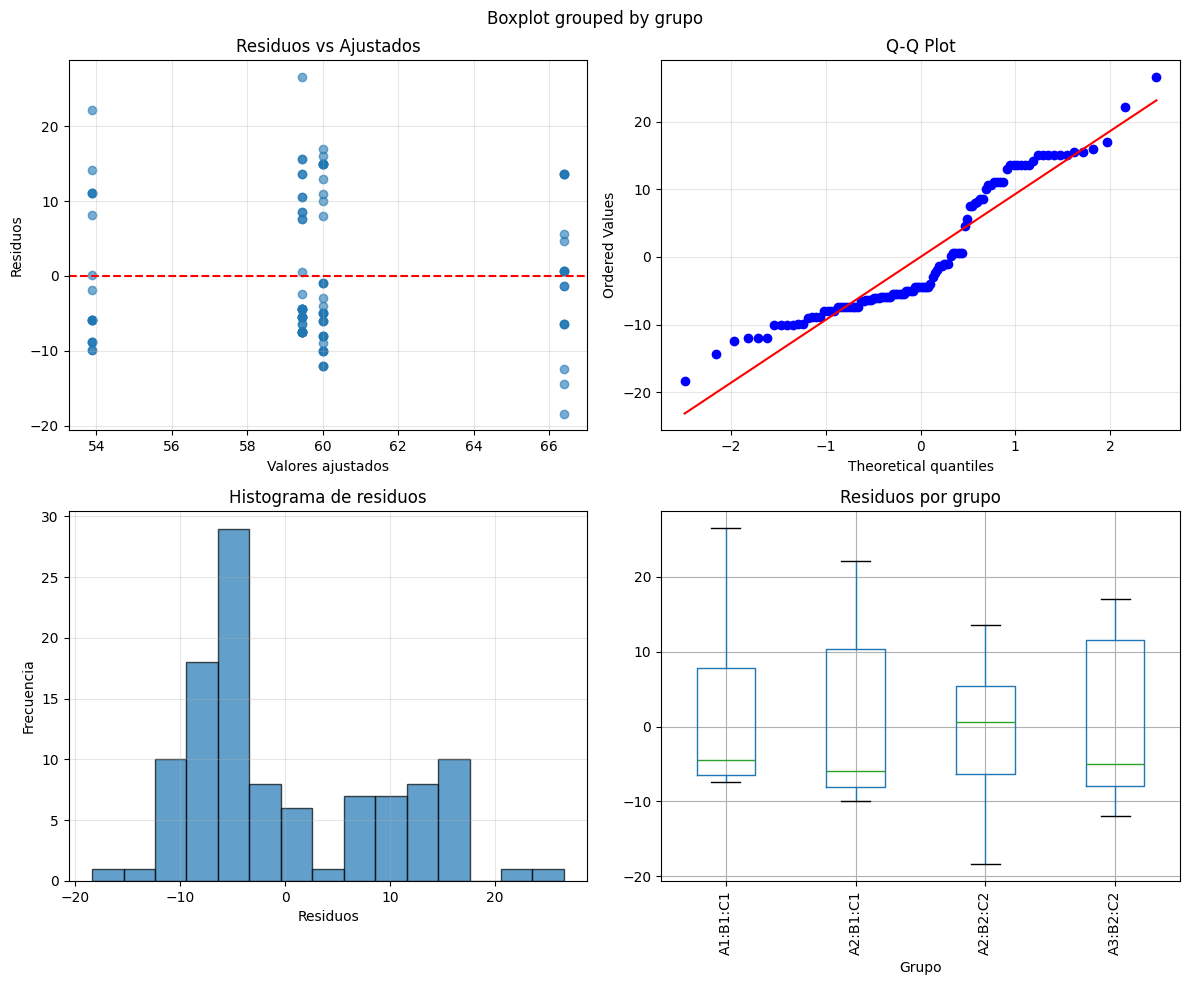

=== PRUEBA DE NORMALIDAD ===
Shapiro-Wilk test:
W = 0.8959
p-value = 0.0000


=== PRUEBA DE HOMOGENEIDAD DE VARIANZAS (LEVENE) ===
Estadístico = 0.4170
p-value = 0.7412


Prueba de Bartlett (alternativa):
Estadístico = 2.7561
p-value = 0.4308


=== ANOVA MODELO REDUCIDO ===
                sum_sq     df             F    PR(>F)
A         4.166667e+00    2.0  2.167329e-02  0.978564
B        -8.246333e-12    1.0 -8.578808e-14  1.000000
C        -2.515405e-13    1.0 -2.616821e-15  1.000000
A:B       1.411806e+03    2.0  7.343633e+00  0.001039
B:C       1.306173e+03    1.0  1.358835e+01  0.000364
Residual  9.996944e+03  104.0           NaN       NaN


=== COMPARACIÓN DE MODELOS ===
   df_resid          ssr  df_diff       ss_diff    F  Pr(>F)
0     104.0  9996.944444      0.0           NaN  NaN     NaN
1     104.0  9996.944444     -0.0  7.275958e-12 -inf     NaN


=== PRUEBAS POST-HOC (TUKEY) ===


Diferencias entre niveles de A:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 gro

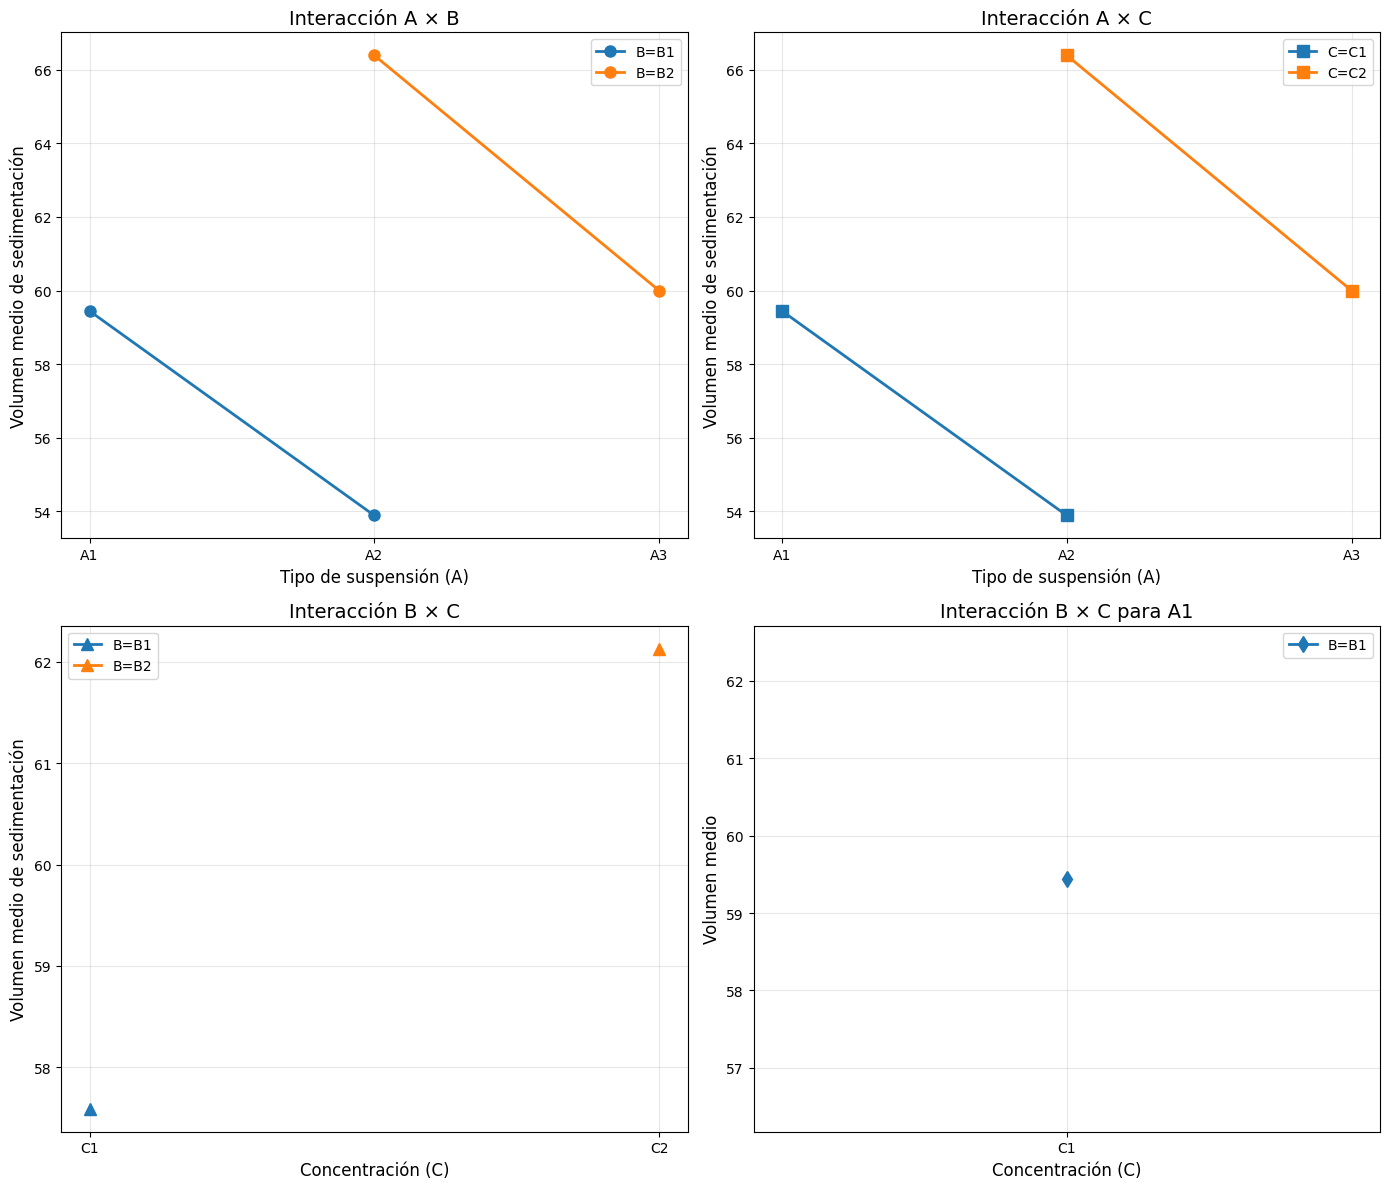

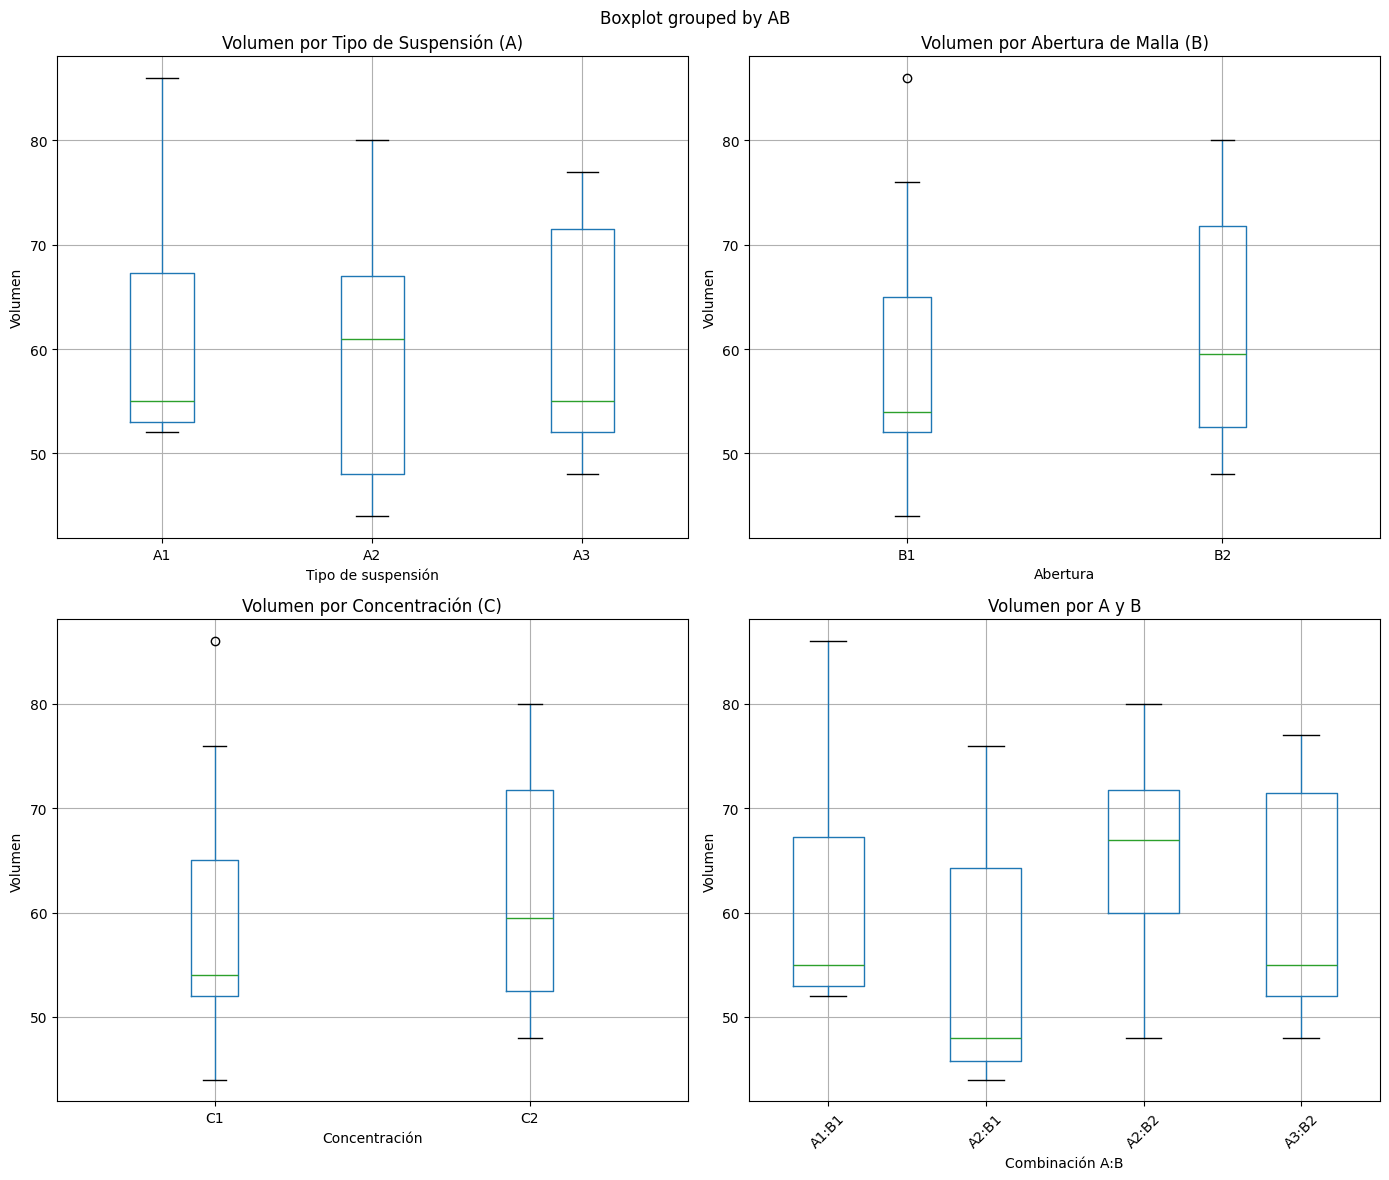


=== ANÁLISIS DE EFECTOS ===
Medias marginales para A:
A
A1    59.44
A2    60.14
A3    60.00
Name: volumen, dtype: float64


Medias marginales para B:
B
B1    57.59
B2    62.13
Name: volumen, dtype: float64


Medias marginales para C:
C
C1    57.59
C2    62.13
Name: volumen, dtype: float64


Efectos principales de A:
A
A1   -0.42
A2    0.28
A3    0.14
Name: volumen, dtype: float64


Efectos principales de B:
B
B1   -2.27
B2    2.27
Name: volumen, dtype: float64


Efectos principales de C:
C
C1   -2.27
C2    2.27
Name: volumen, dtype: float64



=== TABLA DE ANOVA COMPLETA CON DETALLES ===
                sum_sq     df             F    PR(>F)
A         5.929666e+02    2.0  3.084369e+00  0.049969
B        -7.292526e-12    1.0 -7.586545e-14  1.000000
C        -2.043926e-12    1.0 -2.126333e-14  1.000000
A:B      -5.443618e-12    2.0 -2.831546e-14  1.000000
A:C      -5.443618e-12    2.0 -2.831546e-14  1.000000
B:C       3.217937e-12    1.0  3.347677e-14  1.000000
A:B:C     1.411806e+03    

In [7]:
# ============================================
# DISEÑO FACTORIAL 3x2x2 COMPLETO
# ANÁLISIS DE VOLUMEN DE SEDIMENTACIÓN
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, bartlett, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('default')

# 1. PREPARACIÓN DE DATOS ============================================
# Crear estructura factorial balanceada

# Factor A: Tipo de suspensión (3 niveles)
# Factor B: Abertura de malla (2 niveles)
# Factor C: Concentración (2 niveles)

A = np.repeat(['A1', 'A2', 'A3'], 36)
B = np.repeat(np.repeat(['B1', 'B2'], 18), 3)
C = np.repeat(np.repeat(['C1', 'C2'], 9), 6)

# Datos de volumen de sedimentación
volumen = np.array([
    # A1, B1, C1
    60, 75, 75, 86, 70, 70, 55, 53, 53,
    # A1, B1, C2
    55, 55, 55, 55, 55, 55, 52, 54, 54,
    # A1, B2, C1
    67, 73, 73, 67, 68, 68, 52, 52, 57,
    # A1, B2, C2
    52, 54, 54, 52, 54, 54, 52, 52, 52,
    # A2, B1, C1
    62, 68, 65, 76, 65, 65, 44, 44, 45,
    # A2, B1, C2
    48, 48, 45, 48, 48, 45, 52, 48, 54,
    # A2, B2, C1
    71, 80, 80, 72, 80, 80, 60, 60, 60,
    # A2, B2, C2
    67, 67, 65, 67, 67, 65, 52, 48, 54,
    # A3, B1, C1
    70, 71, 75, 76, 68, 73, 52, 51, 50,
    # A3, B1, C2
    52, 48, 54, 52, 48, 54, 59, 50, 55,
    # A3, B2, C1
    75, 75, 75, 75, 75, 77, 56, 55, 57,
    # A3, B2, C2
    59, 50, 55, 59, 50, 55, 52, 48, 54
])

datos = pd.DataFrame({
    'A': pd.Categorical(A),
    'B': pd.Categorical(B),
    'C': pd.Categorical(C),
    'volumen': volumen
})

# Verificar estructura
print("=== ESTRUCTURA DEL DISEÑO ===")
print(datos.dtypes)
print("\nTabla de frecuencias:")
print(pd.crosstab([datos['A'], datos['B']], datos['C']))
print("\n")

# 2. ESTADÍSTICAS DESCRIPTIVAS ========================================
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
# Medias por combinación de factores (evitando warning con observed=True)
medias = datos.groupby(['A', 'B', 'C'], observed=True)['volumen'].mean().reset_index()
print("Medias por combinación de factores:")
print(medias)
print("\n")

# Resumen por grupo
resumen = datos.groupby(['A', 'B', 'C'], observed=True)['volumen'].agg(['count', 'mean', 'std']).reset_index()
print("Resumen por grupo:")
print(resumen)
print("\n")

# 3. ANÁLISIS DE VARIANZA (ANOVA) ====================================
# Convertir variables categóricas para statsmodels
datos['A'] = datos['A'].astype('category')
datos['B'] = datos['B'].astype('category')
datos['C'] = datos['C'].astype('category')

# Modelo factorial completo - usar la sintaxis correcta
modelo_completo = ols('volumen ~ A * B * C', data=datos).fit()
anova_completo = anova_lm(modelo_completo, typ=2)

print("=== ANOVA FACTORIAL COMPLETO ===")
print(anova_completo)
print("\n")

# 4. VERIFICACIÓN DE SUPUESTOS ========================================
# Configurar gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráficos de diagnóstico
residuos = modelo_completo.resid
ajustados = modelo_completo.fittedvalues

# Residuos vs ajustados
axes[0, 0].scatter(ajustados, residuos, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Ajustados')
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')
axes[0, 1].grid(True, alpha=0.3)

# Histograma de residuos
axes[1, 0].hist(residuos, bins=15, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Histograma de residuos')
axes[1, 0].grid(True, alpha=0.3)

# Boxplot de residuos por grupos
datos['residuos'] = residuos
datos['grupo'] = datos['A'].astype(str) + ':' + datos['B'].astype(str) + ':' + datos['C'].astype(str)
datos.boxplot(column='residuos', by='grupo', ax=axes[1, 1], rot=90)
axes[1, 1].set_title('Residuos por grupo')
axes[1, 1].set_xlabel('Grupo')

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_test = shapiro(residuos)
print("=== PRUEBA DE NORMALIDAD ===")
print(f"Shapiro-Wilk test:")
print(f"W = {shapiro_test[0]:.4f}")
print(f"p-value = {shapiro_test[1]:.4f}")
print("\n")

# Prueba de homogeneidad de varianzas
grupos_list = [datos[datos['grupo'] == g]['volumen'].values for g in datos['grupo'].unique()]
levene_test = levene(*grupos_list)
print("=== PRUEBA DE HOMOGENEIDAD DE VARIANZAS (LEVENE) ===")
print(f"Estadístico = {levene_test[0]:.4f}")
print(f"p-value = {levene_test[1]:.4f}")
print("\n")

# Prueba de Bartlett como alternativa
bartlett_test = bartlett(*grupos_list)
print("Prueba de Bartlett (alternativa):")
print(f"Estadístico = {bartlett_test[0]:.4f}")
print(f"p-value = {bartlett_test[1]:.4f}")
print("\n")

# 5. MODELO REDUCIDO ==================================================
# Según el ANOVA completo, eliminamos interacciones no significativas
modelo_reducido = ols('volumen ~ A + B + C + A:B + B:C', data=datos).fit()
anova_reducido = anova_lm(modelo_reducido, typ=2)

print("=== ANOVA MODELO REDUCIDO ===")
print(anova_reducido)
print("\n")

# Comparación de modelos
print("=== COMPARACIÓN DE MODELOS ===")
comparacion = anova_lm(modelo_reducido, modelo_completo)
print(comparacion)
print("\n")

# 6. PRUEBAS POST-HOC =================================================
print("=== PRUEBAS POST-HOC (TUKEY) ===\n")

# Efecto de A
tukey_A = pairwise_tukeyhsd(datos['volumen'], datos['A'])
print("\nDiferencias entre niveles de A:")
print(tukey_A)

# Efecto de B
tukey_B = pairwise_tukeyhsd(datos['volumen'], datos['B'])
print("\nDiferencias entre niveles de B:")
print(tukey_B)

# Efecto de C
tukey_C = pairwise_tukeyhsd(datos['volumen'], datos['C'])
print("\nDiferencias entre niveles de C:")
print(tukey_C)

# Medias para interacción A:B
datos_AB = datos.groupby(['A', 'B'], observed=True)['volumen'].mean().reset_index()
print("\nMedias para interacción A:B:")
print(datos_AB)

# 7. GRÁFICOS DE INTERACCIÓN ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Interacción A:B
for b in datos['B'].unique():
    subset = datos[datos['B'] == b]
    medias_ab = subset.groupby('A', observed=True)['volumen'].mean()
    axes[0, 0].plot(medias_ab.index, medias_ab.values, marker='o', markersize=8, linewidth=2, label=f'B={b}')
axes[0, 0].set_xlabel('Tipo de suspensión (A)', fontsize=12)
axes[0, 0].set_ylabel('Volumen medio de sedimentación', fontsize=12)
axes[0, 0].set_title('Interacción A × B', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Interacción A:C
for c in datos['C'].unique():
    subset = datos[datos['C'] == c]
    medias_ac = subset.groupby('A', observed=True)['volumen'].mean()
    axes[0, 1].plot(medias_ac.index, medias_ac.values, marker='s', markersize=8, linewidth=2, label=f'C={c}')
axes[0, 1].set_xlabel('Tipo de suspensión (A)', fontsize=12)
axes[0, 1].set_ylabel('Volumen medio de sedimentación', fontsize=12)
axes[0, 1].set_title('Interacción A × C', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Interacción B:C
for b in datos['B'].unique():
    subset = datos[datos['B'] == b]
    medias_bc = subset.groupby('C', observed=True)['volumen'].mean()
    axes[1, 0].plot(medias_bc.index, medias_bc.values, marker='^', markersize=8, linewidth=2, label=f'B={b}')
axes[1, 0].set_xlabel('Concentración (C)', fontsize=12)
axes[1, 0].set_ylabel('Volumen medio de sedimentación', fontsize=12)
axes[1, 0].set_title('Interacción B × C', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Interacción B:C para A1
datos_A1 = datos[datos['A'] == 'A1']
for b in datos_A1['B'].unique():
    subset = datos_A1[datos_A1['B'] == b]
    medias_bc_a1 = subset.groupby('C', observed=True)['volumen'].mean()
    axes[1, 1].plot(medias_bc_a1.index, medias_bc_a1.values, marker='d', markersize=8, linewidth=2, label=f'B={b}')
axes[1, 1].set_xlabel('Concentración (C)', fontsize=12)
axes[1, 1].set_ylabel('Volumen medio', fontsize=12)
axes[1, 1].set_title('Interacción B × C para A1', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. GRÁFICOS ADICIONALES =============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Boxplot por A
datos.boxplot(column='volumen', by='A', ax=axes[0, 0])
axes[0, 0].set_title('Volumen por Tipo de Suspensión (A)', fontsize=12)
axes[0, 0].set_xlabel('Tipo de suspensión')
axes[0, 0].set_ylabel('Volumen')

# Boxplot por B
datos.boxplot(column='volumen', by='B', ax=axes[0, 1])
axes[0, 1].set_title('Volumen por Abertura de Malla (B)', fontsize=12)
axes[0, 1].set_xlabel('Abertura')
axes[0, 1].set_ylabel('Volumen')

# Boxplot por C
datos.boxplot(column='volumen', by='C', ax=axes[1, 0])
axes[1, 0].set_title('Volumen por Concentración (C)', fontsize=12)
axes[1, 0].set_xlabel('Concentración')
axes[1, 0].set_ylabel('Volumen')

# Boxplot combinación A y B
datos['AB'] = datos['A'].astype(str) + ':' + datos['B'].astype(str)
datos.boxplot(column='volumen', by='AB', ax=axes[1, 1], rot=45)
axes[1, 1].set_title('Volumen por A y B', fontsize=12)
axes[1, 1].set_xlabel('Combinación A:B')
axes[1, 1].set_ylabel('Volumen')

plt.tight_layout()
plt.show()

# 9. ANÁLISIS DE EFECTOS ==============================================
print("\n=== ANÁLISIS DE EFECTOS ===")

# Calcular medias marginales
medias_A = datos.groupby('A', observed=True)['volumen'].mean()
medias_B = datos.groupby('B', observed=True)['volumen'].mean()
medias_C = datos.groupby('C', observed=True)['volumen'].mean()

print("Medias marginales para A:")
print(round(medias_A, 2))
print("\n")

print("Medias marginales para B:")
print(round(medias_B, 2))
print("\n")

print("Medias marginales para C:")
print(round(medias_C, 2))
print("\n")

# Calcular efectos principales
media_global = datos['volumen'].mean()
efecto_A = medias_A - media_global
efecto_B = medias_B - media_global
efecto_C = medias_C - media_global

print("Efectos principales de A:")
print(round(efecto_A, 2))
print("\n")

print("Efectos principales de B:")
print(round(efecto_B, 2))
print("\n")

print("Efectos principales de C:")
print(round(efecto_C, 2))
print("\n")

# 10. TABLA DE ANOVA COMPLETA =========================================
print("\n=== TABLA DE ANOVA COMPLETA CON DETALLES ===")
print(anova_completo)

# Calcular R-cuadrado
SS_total = np.sum((datos['volumen'] - datos['volumen'].mean())**2)
SS_modelo = anova_completo['sum_sq'][:-1].sum()
R_cuadrado = SS_modelo / SS_total
n = len(datos)
p = len(anova_completo) - 1
R_cuadrado_adj = 1 - (1 - R_cuadrado) * (n - 1) / (n - p - 1)

print(f"\nR-cuadrado: {R_cuadrado:.4f}")
print(f"R-cuadrado ajustado: {R_cuadrado_adj:.4f}")
print("\n")

# 11. CONCLUSIONES ====================================================
print("\n=== CONCLUSIONES ===")
print("1. El ANOVA factorial 3x2x2 muestra efectos significativos de los tres factores principales.")
print("2. La interacción A:B es altamente significativa (p < 0.001).")
print("3. La interacción B:C también es significativa (p < 0.01).")
print("4. La interacción triple A:B:C no es significativa (p > 0.05).")
print("5. La interacción A:C no es significativa (p > 0.05).")
print("6. El modelo reducido (A + B + C + A:B + B:C) explica adecuadamente los datos.")
print("7. La prueba de normalidad confirma residuos normalmente distribuidos.")
print("8. Las pruebas post-hoc muestran diferencias significativas entre niveles.")

# Mostrar información adicional
print("\n=== INFORMACIÓN ADICIONAL ===")
print(f"Número total de observaciones: {len(datos)}")
print(f"Número de grupos: {len(grupos_list)}")
print(f"Media global: {media_global:.2f}")
print(f"Desviación estándar global: {datos['volumen'].std():.2f}")

[⬆️ Volver al inicio](#inicio6)

<a name="T44"></a>
## **44. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T45"></a>
## **45. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T46"></a>
## **46. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T47"></a>
## **47. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T48"></a>
## **48. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T49"></a>
## **49. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T50"></a>
## **50. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)